In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
    --------------------------------------- 0.8/56.8 MB 4.5 MB/s eta 0:00:13
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --------------------------------------- 1.0/56.8 MB 4.7 MB/s eta 0:00:12
    --

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\alice.var\\AppData\\Local\\Temp\\pip-unpack-mw8pc83m\\xgboost-3.0.5-py3-none-win_amd64.whl'
Consider using the `--user` option or check the permissions.



In [126]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.types import IntegerType, FloatType, StringType, ArrayType
from pyspark.sql.window import Window
import pyspark.sql.functions as F
import warnings
import xgboost as xgb

warnings.filterwarnings('ignore')

os.environ['JAVA_HOME'] = '/lib/jvm/java-11-openjdk'

# Initialize PySpark Session

In [2]:
spark = (
    SparkSession.builder.appName("PySparkApp")
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.2,com.amazonaws:aws-java-sdk-pom:1.12.365")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR") 
print(spark.version)

:: loading settings :: url = jar:file:/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.0.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ec2-user/.ivy2/cache
The jars for the packages stored in: /home/ec2-user/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-pom added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-93a2c1ec-21d9-479d-b50a-4a7d002486e5;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.2 in central
	found com.amazonaws#aws-java-sdk-bundle;1.11.1026 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
	found com.amazonaws#aws-java-sdk-pom;1.12.365 in central
downloading https://repo1.maven.org/maven2/org/apache/hadoop/hadoop-aws/3.3.2/hadoop-aws-3.3.2.jar ...
	[SUCCESSFUL ] org.apache.hadoop#hadoop-aws;3.3.2!hadoop-aws.jar (919ms)
downloading https://repo1.maven.org/maven2/com/amazonaws/aws-java-sdk-bundle/1.11.1026/aws-java-sdk-bundle-1.11.1026.jar ...
	[SUCCESSFUL ] com.amazonaws#aws-java-sdk-bundle;1.11.1026!aws-java-sdk-bundle.jar (14901ms)
downloading https://re

25/09/05 02:10:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


3.3.0


# Read Tables

In [28]:
window = Window().orderBy(F.lit('dummy'))

df_dbscan_result = spark.read.option('delimiter', ',')\
                            .option('header', True)\
                            .csv(
's3a://tli-sas-analytic-based-table/sandbox/fraud-detection/fraud_agent_ml/model/dbscan_full_feature_new_data/406d151d-aabe-4c14-8b05-029d0f3cc301_20250903083911/data_result.csv'
                            )\
                        .withColumn('dummy_agent_code', F.concat(F.lit('agent_'), F.row_number().over(window)))

cols_name = [ x for x in df_dbscan_result.columns if x not in ['data_set', 'dummy_agent_code']]

df_dbscan_result_edited = df_dbscan_result\
                    .select(
                        'dummy_agent_code',
                        'data_set',
                        *[F.col(x).cast(FloatType()).alias(x) for x in cols_name]
                    )\
                    .toPandas()


In [29]:
df_dbscan_result.groupby('y_pred')\
                .agg(
                    F.countDistinct('dummy_agent_code').alias('num_agents')
                ).show()

+------+----------+
|y_pred|num_agents|
+------+----------+
|     0|     34801|
|     1|       600|
+------+----------+



# Modeling

In [38]:
X = df_dbscan_result_edited[[ x for x in cols_name if x not in ['dummy_agent_code', 'data_set', 'y_true', 'y_pred', 'dist']]]
Y = df_dbscan_result_edited[['y_pred']]

In [44]:
model = xgb.XGBClassifier()
model.fit(X, Y)

In [48]:
Y_prob = model.predict_proba(X)[:, 1]

In [70]:
df_final = df_dbscan_result_edited.copy()
df_final['y_proba'] = Y_prob

# Analysis

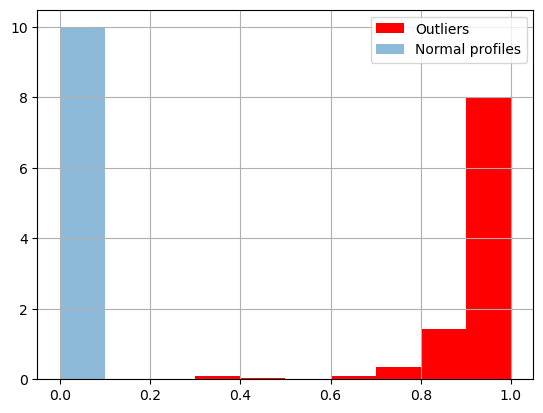

In [104]:
bin_width = 0.1
plt.hist(df_final[df_final['y_pred'] == 1]['y_proba'], label = 'Outliers', 
         density = True, 
         color = 'red',
         bins = np.arange(0, 1+bin_width, bin_width)
        )

plt.hist(df_final[df_final['y_pred'] == 0]['y_proba'], label = 'Normal profiles', 
         density = True, 
         bins = np.arange(0, 1+bin_width, bin_width),
        alpha = 0.5)
plt.legend()
plt.grid()
plt.show()

In [131]:
# dist was not used to train the model, 
# but we want to see the correlation between y_proba and dist
df_final[['y_proba', 'dist']].corr()

,y_proba,dist
y_proba,1.000000,0.882865
dist,0.882865,1.000000


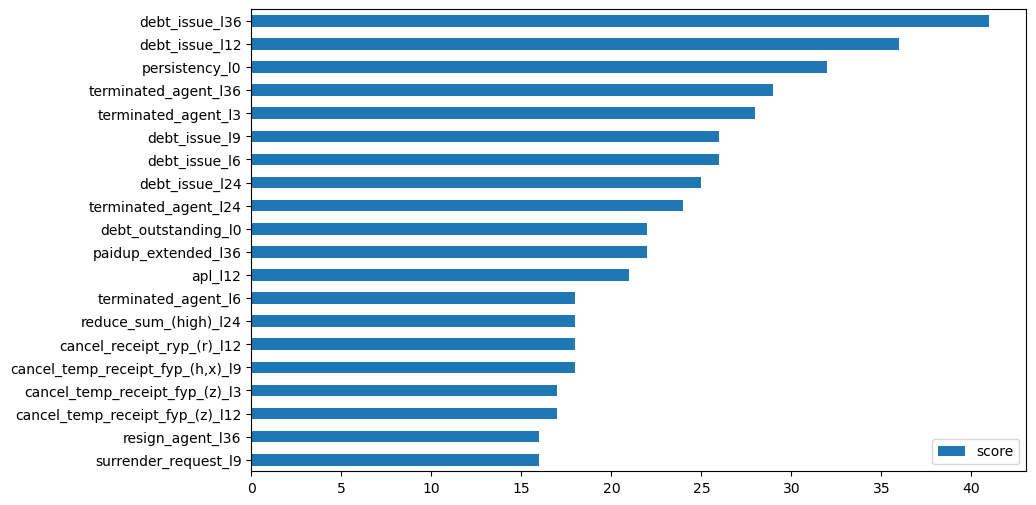

In [124]:
feature_importance = model.get_booster().get_score(importance_type='weight')
keys = list(feature_importance.keys())
values = list(feature_importance.values())

data_importance  = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=True)
data_importance.tail(20).plot(kind='barh', figsize = (10,6))
plt.show()